In [13]:
import cv2
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import pandas as pd
from skimage.feature import hog
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC,LinearSVC
from sklearn.metrics import confusion_matrix,classification_report


In [2]:
human=r'C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\human'
non_human=r'C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\non_human'
RANDOM_STATE=100
TEST_SIZE=0.2
pd.set_option("display.max_columns",None)


In [22]:
import glob
import os

human_d = glob.glob(os.path.join(human, "*.png"))
non_human_d=glob.glob(os.path.join(non_human,'*.png'))

print(len(human_d))
print(len(non_human_d))

1331
750


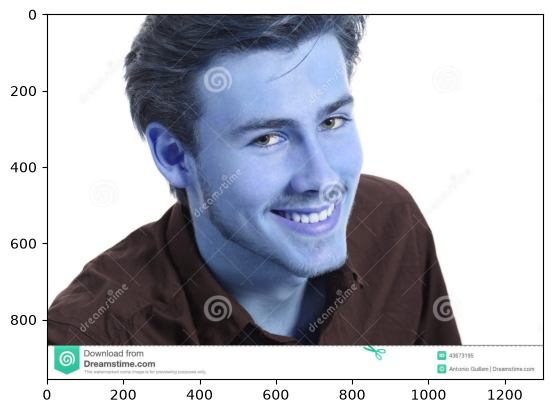

In [38]:
image_color = cv2.imread(human_d[34]) 
plt.imshow(image_color,cmap='gray')

In [30]:
image_color.shape

(128, 128, 3)

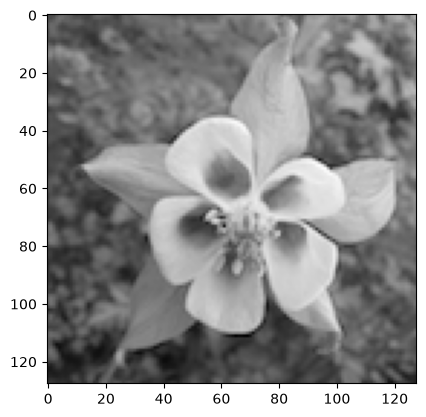

In [35]:
image_gray=cv2.cvtColor(image_color,cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray,cmap='gray')

In [32]:


input_folder = r"C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\human"
output_folder = r"C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\human_resized"

os.makedirs(output_folder, exist_ok=True)

images = glob.glob(os.path.join(input_folder, "*.png"))

for img_path in images:
    img = cv2.imread(img_path)

    # Resize to 128×128
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)

    filename = os.path.basename(img_path)
    cv2.imwrite(os.path.join(output_folder, filename), img)

print("Done!")



Done!


In [34]:
non_human=r'C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\non_human'
output_non_human_folder=r'C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\non_human_resized'
os.makedirs(output_non_human_folder,exist_ok=True)
images=glob.glob(os.path.join(non_human,'*.png'))

for img_path in images:
    img=cv2.imread(img_path)
    img=cv2.resize(img,(128,128),interpolation=cv2.INTER_AREA)
    
    filename=os.path.basename('non_human'+img_path)
    cv2.imwrite(os.path.join(output_non_human_folder,filename),img)
    

In [39]:
human_dataset=r'C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\human_resized'
non_human_dataset=r'C:\Users\kaush\Desktop\SummerBreak\Automous_Car_Design_Code\Face Detection\Dataset\non_human_resized'

In [42]:
human_p=glob.glob(os.path.join(human_dataset,'*.png'))

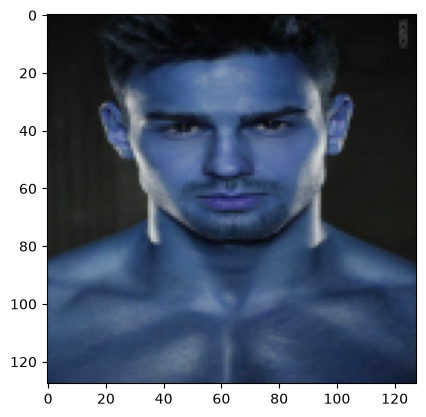

In [47]:
image_c=cv2.imread(human_p[73])
plt.imshow(image_c)

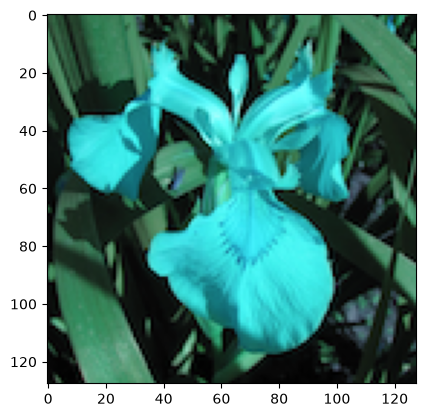

In [48]:
non_human_p=glob.glob(os.path.join(non_human_dataset,'*.png'))
image_n_c=cv2.imread(non_human_p[34])
plt.imshow(image_n_c)

In [50]:
image_g=cv2.cvtColor(image_c,cv2.COLOR_BGR2GRAY)

In [52]:
features,hog_image=hog(image_g,
                        orientations=10,
                        pixels_per_cell=(16,16),
                        cells_per_block=(2,2),
                        transform_sqrt=True,
                        visualize=True,
                        feature_vector=True)
features.shape

(1960,)

In [53]:
hog_image.shape

(128, 128)

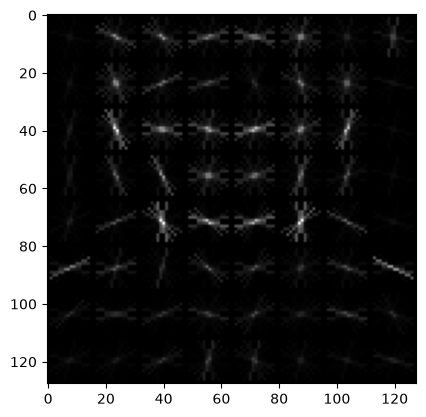

In [54]:
plt.imshow(hog_image,cmap='gray')

In [63]:
human_hog_accum=[]

for img_path in human_p:
    img_c=mpimg.imread(img_path)
    img_g=cv2.cvtColor(img_c,cv2.COLOR_BGR2GRAY)
    features_human,hog_image_human=hog(img_g[:,:],
                           orientations=10,
                           pixels_per_cell=(16,16),
                           cells_per_block=(2,2),
                           transform_sqrt=False,
                           visualize=True,
                           feature_vector=True)
    human_hog_accum.append(features_human)

In [65]:
X_human=np.vstack(human_hog_accum).astype(np.float64)
y_human=np.ones(len(X_human))


In [66]:
X_human.shape

(1331, 1960)

In [67]:
y_human.shape

(1331,)

In [64]:
non_human_hog_accum=[]

for img_path in non_human_p:
    img_c=mpimg.imread(img_path)
    img_g=cv2.cvtColor(img_c,cv2.COLOR_BGR2GRAY)
    features_non_human,hog_image_non_human=hog(img_g[:,:],
                           orientations=10,
                           pixels_per_cell=(16,16),
                           cells_per_block=(2,2),
                           transform_sqrt=False,
                           visualize=True,
                           feature_vector=True)
    non_human_hog_accum.append(features_non_human)

In [68]:
X_non_human=np.vstack(non_human_hog_accum).astype(np.float64)
y_non_human=np.zeros(len(X_non_human))

In [69]:
X_non_human.shape

(750, 1960)

In [70]:
y_non_human.shape

(750,)

In [71]:
X=np.vstack((X_human,X_non_human))
X.shape


(2081, 1960)

In [73]:
y=np.hstack((y_human,y_non_human))
y.shape

(2081,)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=RANDOM_STATE,test_size=TEST_SIZE)

svc=SVC()
lsvc=LinearSVC()

lsvc.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [76]:
svc.fit(X_train,y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [77]:
y_test_pred_svc=svc.predict(X_test)
y_test_pred_lsvc=lsvc.predict(X_test)


In [78]:
cm1=confusion_matrix(y_test,y_test_pred_svc)
cm2=confusion_matrix(y_test,y_test_pred_svc)

<Axes: >

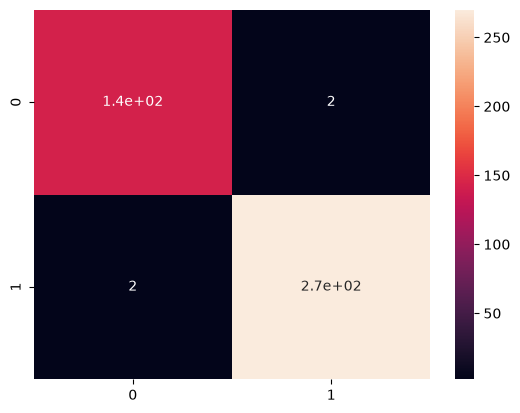

In [79]:
sns.heatmap(cm1,annot=True)

<Axes: >

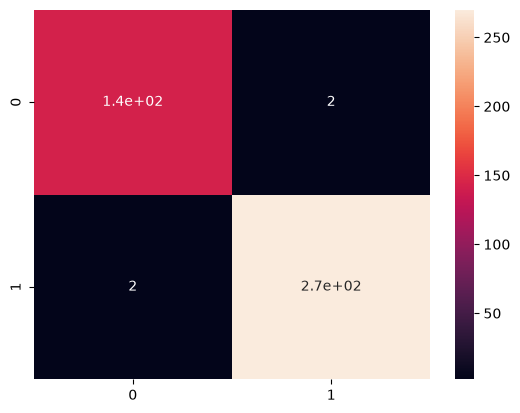

In [80]:
sns.heatmap(cm2,annot=True)

In [85]:
param_grid={
    "C":[0.1,1,10,100],
    'gamma':[1,0.1,0.01],
    'kernel':['rbf']
}

grid=GridSearchCV(estimator=SVC(),
                  param_grid=param_grid,
                  n_jobs=True,
                  refit=True,
                  scoring='neg_root_mean_squared_error')

In [86]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of info

In [87]:
grid.best_params_
grid.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [94]:
final_svc=SVC(C=10,gamma=0.1,kernel='rbf')
final_svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [95]:
y_test_pred_result=final_svc.predict(X_test)

<Axes: >

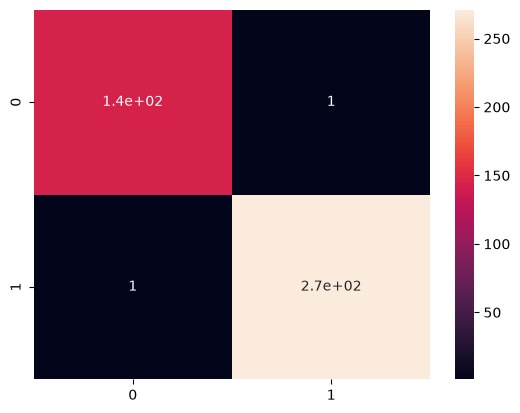

In [96]:
cm3=confusion_matrix(y_test,y_test_pred_result)
sns.heatmap(cm3,annot=True)

In [110]:
test=cv2.imread(non_human_p[34])
test=cv2.cvtColor(test,cv2.COLOR_BGR2GRAY)
hog_test_feature,hog_image_test=hog(test,orientations=10,pixels_per_cell=(16,16),cells_per_block=(2,2),visualize=True,transform_sqrt=False,feature_vector=True)

# plt.imshow(test)

In [111]:
print(hog_image_test.shape)

(128, 128)


In [112]:
print(X_train.shape)

(1664, 1960)


In [115]:

y=final_svc.predict(hog_test_feature.reshape(1,-1))

In [116]:
print(y)

[0.]


In [118]:
from joblib import dump
Model_dir='MODEL'
os.makedirs(Model_dir,exist_ok=True)
model_path=os.path.join(Model_dir,'face_detection.joblib')
dump(final_svc,model_path)


['MODEL\\face_detection.joblib']